# KingSpatialLikelihood Demo

This notebook walks through the full workflow for `KingSpatialLikelihood`, the high-level wrapper that:
1. Fits King PSF parameters (α, β) to simulated signal events as a function of user-defined observables (e.g. reconstructed energy)
2. Interpolates those parameters per-event at runtime
3. Returns per-event PDF values for use in a spatial likelihood

We use synthetic Monte Carlo so the true parameters are known, allowing direct verification of each step.

## Contents
1. Generate synthetic MC signal events with known King PSF
2. Fit `KingSpatialLikelihood` and inspect the fitted parameters
3. Set trial events at a point source and evaluate the PDF
4. Verification plots: PDF vs distance, normalization, γ interpolation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from kingmaker.pdf import KingPDF
from kingmaker.wrapper import KingSpatialLikelihood
from kingmaker.utils import angular_distance

plt.style.use('seaborn-v0_8-darkgrid')
rng = np.random.default_rng(42)

## 1. Generate synthetic MC signal events

We simulate a detector whose angular resolution improves with energy: at low energy the PSF is wide (large α), at high energy it is narrow. We assign three energy bins with distinct, known King parameters.

Each event is generated by:
- Drawing an angular separation ψ from `King(α, β)` via `KingPDF.sample()`
- Drawing a random azimuth φ uniformly on [0, 2π)
- Offsetting a random true sky position by (ψ, φ) to get the reconstructed position

The structured array includes all fields required by `KingPSFFitter`:
- `ra`, `dec`: reconstructed equatorial coordinates (radians)
- `trueRa`, `trueDec`: true equatorial coordinates (radians)
- `ow`: per-event weight (oneweight); set to 1 here
- `true_energy`: true neutrino energy (GeV)
- `log10_energy`: reconstructed energy proxy used for parameterisation

In [2]:
# --- True PSF parameters per energy bin ---
# Resolution improves (smaller alpha) at higher energy, a typical detector behaviour.
log10_e_bin_edges = np.array([2.0, 3.0, 4.0, 5.0])          # log10(E/GeV) bin edges
log10_e_centers   = (log10_e_bin_edges[:-1] + log10_e_bin_edges[1:]) / 2  # [2.5, 3.5, 4.5]
true_alphas_deg   = np.array([12.0, 5.0, 1.5])               # degrees
true_betas        = np.array([ 2.5, 2.5, 2.5])
n_per_bin         = 8_000
n_total           = n_per_bin * len(log10_e_centers)

print("True MC parameters:")
print(f"  log10(E) bin edges : {log10_e_bin_edges}")
print(f"  log10(E) centers   : {log10_e_centers}")
print(f"  true alpha (deg)   : {true_alphas_deg}")
print(f"  true beta          : {true_betas}")

# --- Build structured array ---
dtype = np.dtype([
    ('ra',           np.float64),
    ('dec',          np.float64),
    ('trueRa',       np.float64),
    ('trueDec',      np.float64),
    ('ow',           np.float64),
    ('true_energy',  np.float64),
    ('log10_energy', np.float64),
])
mc = np.zeros(n_total, dtype=dtype)

king = KingPDF()

for i, (loge, alpha_deg, beta) in enumerate(zip(log10_e_centers, true_alphas_deg, true_betas)):
    alpha = np.deg2rad(alpha_deg)
    sl    = slice(i * n_per_bin, (i + 1) * n_per_bin)

    # Draw angular separations and random azimuths
    psi = king.sample(n_per_bin, alpha, beta, rng=rng)
    phi = rng.uniform(0, 2 * np.pi, n_per_bin)

    # Uniformly distributed true positions on the sphere
    true_ra  = rng.uniform(0, 2 * np.pi, n_per_bin)
    true_dec = np.arcsin(rng.uniform(-1, 1, n_per_bin))

    # Reco position = true position + angular offset (ψ, φ)
    reco_dec = np.clip(true_dec + psi * np.sin(phi), -np.pi / 2, np.pi / 2)
    reco_ra  = (true_ra  + psi * np.cos(phi) / np.cos(true_dec)) % (2 * np.pi)

    mc['ra'][sl]           = reco_ra
    mc['dec'][sl]          = reco_dec
    mc['trueRa'][sl]       = true_ra
    mc['trueDec'][sl]      = true_dec
    mc['ow'][sl]           = 1.0
    mc['true_energy'][sl]  = 10 ** loge
    # Smear reconstructed log-energy slightly to simulate finite resolution
    mc['log10_energy'][sl] = loge + rng.normal(0, 0.15, n_per_bin)

print(f"\nGenerated {n_total} MC signal events ({n_per_bin} per energy bin)")

True MC parameters:
  log10(E) bin edges : [2. 3. 4. 5.]
  log10(E) centers   : [2.5 3.5 4.5]
  true alpha (deg)   : [12.   5.   1.5]
  true beta          : [2.5 2.5 2.5]

Generated 24000 MC signal events (8000 per energy bin)


### 1a. Verify MC angular error distributions

Before fitting, confirm that each energy bin's angular errors follow the expected King distribution. The histograms (normalised to units of 1/sr) should closely follow the true King PDF overlaid in red.

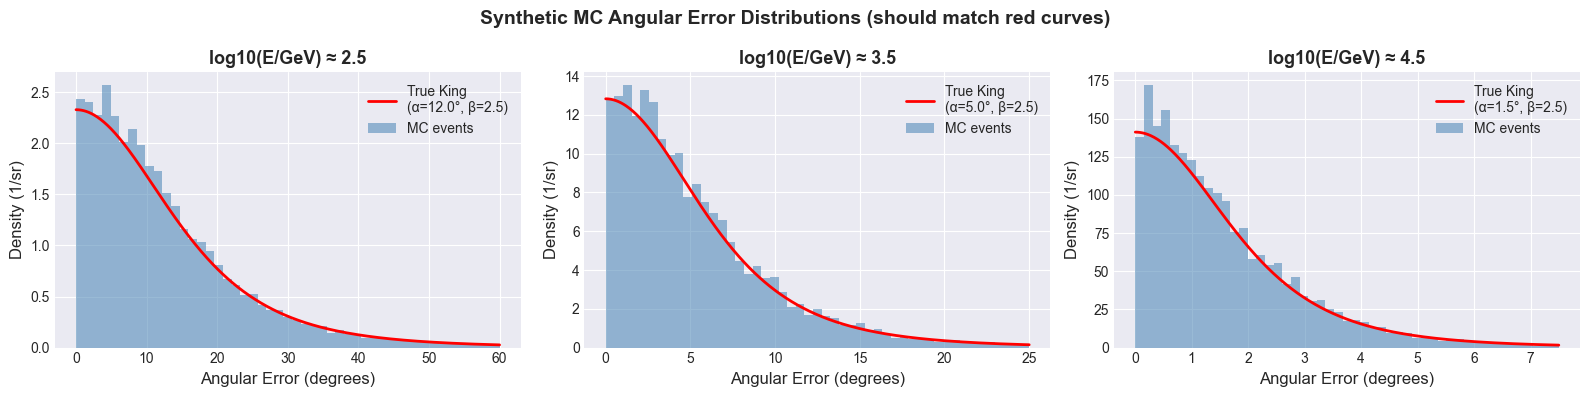

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)

for i, (loge, alpha_deg, beta) in enumerate(zip(log10_e_centers, true_alphas_deg, true_betas)):
    sl    = slice(i * n_per_bin, (i + 1) * n_per_bin)
    alpha = np.deg2rad(alpha_deg)

    # Angular distance between reco and true position
    dpsi = angular_distance(mc['ra'][sl], mc['dec'][sl],
                            mc['trueRa'][sl], mc['trueDec'][sl])

    # Histogram normalised to PDF units (1/steradian)
    bins    = np.linspace(0, 5 * alpha, 50)
    hist, edges = np.histogram(dpsi, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    widths  = np.diff(edges)
    solid_angle = 2 * np.pi * np.sin(centers) * widths
    density = hist / (hist.sum() * solid_angle)

    axes[i].bar(np.degrees(centers), density, width=np.degrees(widths),
                alpha=0.55, color='steelblue', label='MC events')

    psi_fine = np.linspace(1e-6, 5 * alpha, 500)
    axes[i].plot(np.degrees(psi_fine),
                 king.pdf(psi_fine, alpha, beta),
                 'r-', linewidth=2,
                 label=f'True King\n(α={alpha_deg}°, β={beta})')

    axes[i].set_xlabel('Angular Error (degrees)', fontsize=12)
    axes[i].set_ylabel('Density (1/sr)', fontsize=12)
    axes[i].set_title(f'log10(E/GeV) ≈ {loge:.1f}', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=10)

plt.suptitle('Synthetic MC Angular Error Distributions (should match red curves)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Fit KingSpatialLikelihood

`KingSpatialLikelihood` wraps `KingPSFFitter` internally. On construction it:
- Bins the MC by the parametrisation observable(s)
- Fits King parameters in each bin for each spectral index
- Stores the fitted arrays for runtime interpolation

Key constructor arguments:
- `signal_events`: the structured MC array
- `parametrization_bins`: dict mapping field name → bin edges
- `spectral_indices`: list of γ values at which to fit (for energy-reweighted fits)
- `cache_parameters`: if True, saves/loads fits from disk

In [4]:
wrapper = KingSpatialLikelihood(
    signal_events        = mc,
    parametrization_bins = {'log10_energy': log10_e_bin_edges},
    spectral_indices     = [2.0, 3.0],
    angular_cutoff       = np.pi,
    cache_parameters     = False,   # disable caching for this demo
)

print("KingSpatialLikelihood initialised successfully.")
print(f"  alpha_values shape : {wrapper.alpha_values.shape}  (n_spectral_indices × n_energy_bins)")
print(f"  beta_values  shape : {wrapper.beta_values.shape}")
print(f"  spectral_indices   : {wrapper.spectral_indices}")

Fitting King PSF in 3 bins...
  Spectral indices: [2. 3.]
  Binning dimensions: ['log10_energy']

  Spectral index γ = 2.00
    Fitted 3 bins, skipped 0 bins

  Spectral index γ = 3.00
    Fitted 3 bins, skipped 0 bins

Fitting complete!
KingSpatialLikelihood initialised successfully.
  alpha_values shape : (2, 3)  (n_spectral_indices × n_energy_bins)
  beta_values  shape : (2, 3)
  spectral_indices   : [2. 3.]


## 3. Verify fitted parameters

The fitted α and β values in each energy bin should closely recover the true values we used when generating the MC. Any systematic offset would indicate a problem with the fitter or the bin alignment.

/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_21335/1582955010.py:30: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/xz/hwb936c16hv507dyhyngvbhm0000gn/T/ipykernel_21335/1582955010.py:30: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


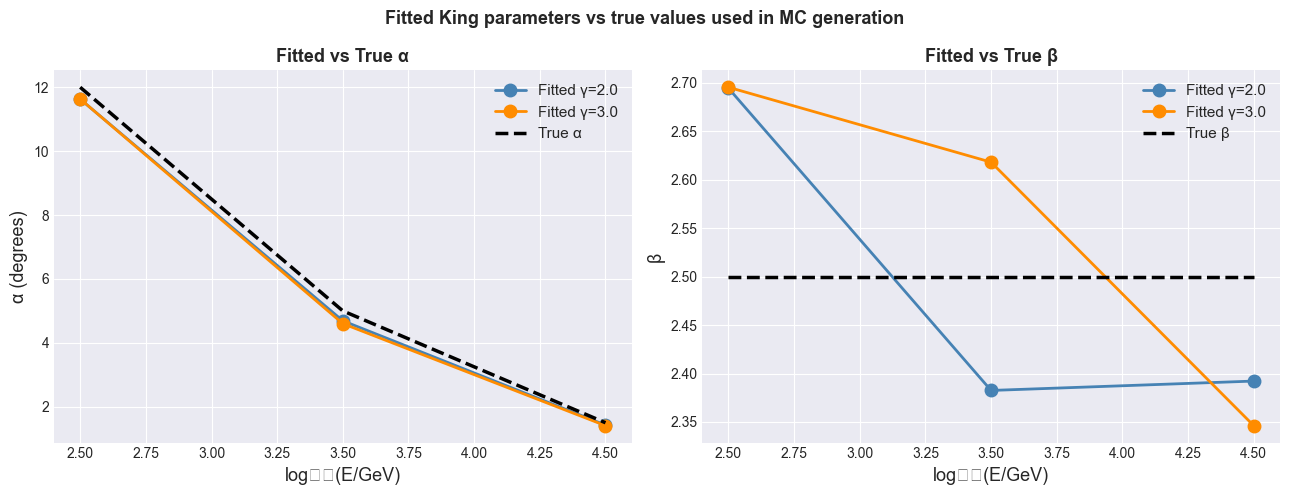

Fitted α values (degrees):
  γ=2.0: [11.62864608  4.69057219  1.42711957]  (true: [12.   5.   1.5])
  γ=3.0: [11.63178976  4.60184524  1.40843384]  (true: [12.   5.   1.5])

Fitted β values:
  γ=2.0: [2.69452316 2.38252765 2.39220676]  (true: [2.5 2.5 2.5])
  γ=3.0: [2.69548215 2.61813931 2.34617852]  (true: [2.5 2.5 2.5])


In [5]:
bin_centers = (log10_e_bin_edges[:-1] + log10_e_bin_edges[1:]) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = ['steelblue', 'darkorange']
for g_idx, (gamma, color) in enumerate(zip(wrapper.spectral_indices, colors)):
    ax1.plot(bin_centers, np.degrees(wrapper.alpha_values[g_idx]),
             'o-', markersize=9, linewidth=2, color=color, label=f'Fitted γ={gamma:.1f}')
    ax2.plot(bin_centers, wrapper.beta_values[g_idx],
             'o-', markersize=9, linewidth=2, color=color, label=f'Fitted γ={gamma:.1f}')

# Overlay true values at the MC generation energies
ax1.plot(log10_e_centers, true_alphas_deg, 'k--', linewidth=2.5, label='True α')
ax2.plot(log10_e_centers, true_betas,      'k--', linewidth=2.5, label='True β')

ax1.set_xlabel('log₁₀(E/GeV)', fontsize=13)
ax1.set_ylabel('α (degrees)', fontsize=13)
ax1.set_title('Fitted vs True α', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True)

ax2.set_xlabel('log₁₀(E/GeV)', fontsize=13)
ax2.set_ylabel('β', fontsize=13)
ax2.set_title('Fitted vs True β', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True)

plt.suptitle('Fitted King parameters vs true values used in MC generation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Fitted α values (degrees):")
for g_idx, gamma in enumerate(wrapper.spectral_indices):
    fitted = np.degrees(wrapper.alpha_values[g_idx])
    print(f"  γ={gamma:.1f}: {fitted}  (true: {true_alphas_deg})")
print("\nFitted β values:")
for g_idx, gamma in enumerate(wrapper.spectral_indices):
    fitted = wrapper.beta_values[g_idx]
    print(f"  γ={gamma:.1f}: {fitted}  (true: {true_betas})")

## 4. Set events and evaluate the PDF

In a real analysis the workflow is:
1. Call `set_events(trial_events, source_ras, source_decs)` once per trial — this caches per-event King parameters and PDF values
2. Call `evaluate_pdf(trial_events, gamma)` as many times as needed (different γ values) — this is cheap because the heavy work was done in step 1

Here we generate test events drawn from `King(α=5°, β=2.5)` near a known point source at the middle energy (`log10_energy ≈ 3.5`), where the fitted parameters should be close to those true values.

In [6]:
# Point source position
source_ra  = np.array([1.0])   # radians
source_dec = np.array([0.3])   # radians (~17°)

# True PSF for these test events — matches the middle energy bin
test_loge  = 3.5
test_alpha = np.deg2rad(5.0)
test_beta  = 2.5
n_test     = 3_000

# Draw angular separations and random azimuths
psi_test = king.sample(n_test, test_alpha, test_beta, rng=rng)
phi_test = rng.uniform(0, 2 * np.pi, n_test)

# Offset from the source position
test_dec = np.clip(
    source_dec[0] + psi_test * np.sin(phi_test), -np.pi / 2, np.pi / 2
)
test_ra  = (
    source_ra[0] + psi_test * np.cos(phi_test) / np.cos(source_dec[0])
) % (2 * np.pi)

test_dtype = np.dtype([
    ('ra',           np.float64),
    ('dec',          np.float64),
    ('log10_energy', np.float64),
])
test_events = np.zeros(n_test, dtype=test_dtype)
test_events['ra']           = test_ra
test_events['dec']          = test_dec
test_events['log10_energy'] = test_loge + rng.normal(0, 0.1, n_test)

print(f"Generated {n_test} test events")
print(f"  Source: RA={np.degrees(source_ra[0]):.1f}°, Dec={np.degrees(source_dec[0]):.1f}°")
print(f"  True PSF used: α={np.degrees(test_alpha):.1f}°, β={test_beta}")
print(f"  log10(E) = {test_loge} ± 0.1  (smeared reco energy)")

Generated 3000 test events
  Source: RA=57.3°, Dec=17.2°
  True PSF used: α=5.0°, β=2.5
  log10(E) = 3.5 ± 0.1  (smeared reco energy)


In [7]:
# set_events() does all the per-event heavy lifting:
#   - interpolates fitted (alpha, beta) at each event's log10_energy
#   - computes angular distance from the source
#   - evaluates King PDF for each fitted spectral index
wrapper.set_events(test_events, source_ras=source_ra, source_decs=source_dec)

# evaluate_pdf() just returns the cached values (or interpolates between them)
pdf_gamma2  = wrapper.evaluate_pdf(test_events, gamma=2.0)
pdf_gamma25 = wrapper.evaluate_pdf(test_events, gamma=2.5)   # interpolated
pdf_gamma3  = wrapper.evaluate_pdf(test_events, gamma=3.0)

print("PDF summary (1/sr):")
for label, vals in [('γ=2.0 (fitted)', pdf_gamma2),
                    ('γ=2.5 (interp)', pdf_gamma25),
                    ('γ=3.0 (fitted)', pdf_gamma3)]:
    print(f"  {label}: median={np.median(vals):.3e}  "
          f"min={vals.min():.3e}  max={vals.max():.3e}")

PDF summary (1/sr):
  γ=2.0 (fitted): median=4.058e+00  min=2.343e-04  max=2.191e+01
  γ=2.5 (interp): median=4.124e+00  min=1.679e-04  max=2.275e+01
  γ=3.0 (fitted): median=4.189e+00  min=1.016e-04  max=2.358e+01


## 5. Verification: PDF values vs angular distance

Each event's PDF value should trace `King(ψ | α_fitted, β_fitted)` where ψ is the event's angular distance from the source. We overlay:
- **Blue dots**: `evaluate_pdf()` output for each test event
- **Red curve**: King PDF evaluated at the fitted parameters for this energy bin
- **Green dashed**: King PDF at the true generation parameters (ground truth)

Good agreement between the three indicates the fitting, interpolation, and evaluation pipeline is working correctly.

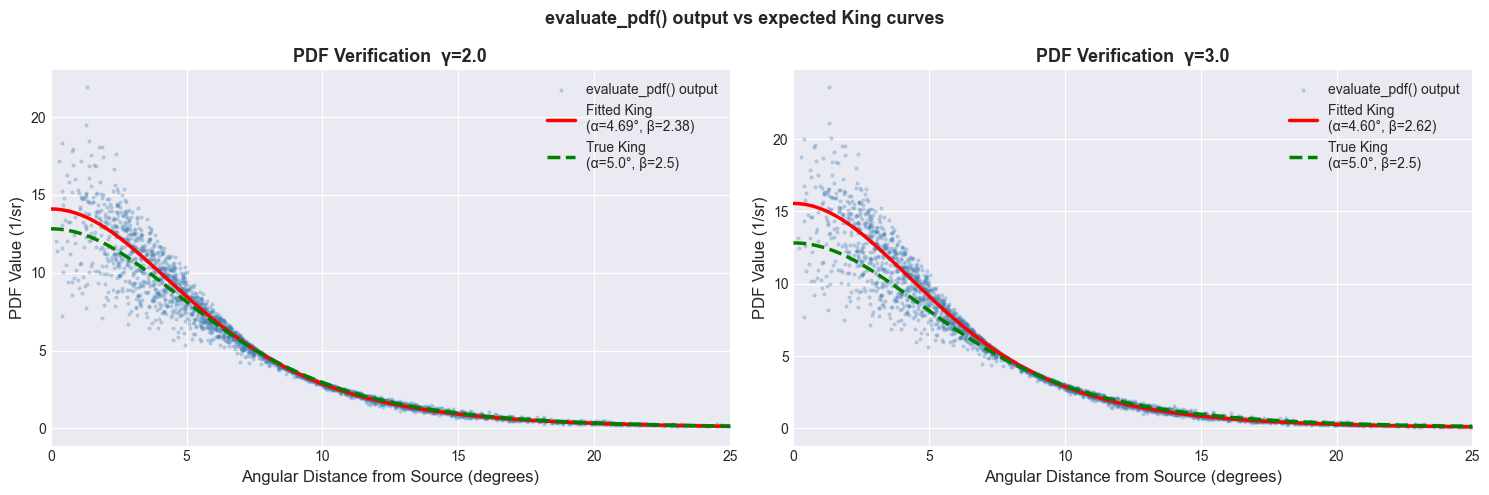

In [9]:
# True angular distances (recomputed for reference)
true_dists = angular_distance(
    test_events['ra'], test_events['dec'], source_ra[0], source_dec[0]
)

# Fitted parameters at the test energy (interpolated between bin centers)
def fitted_params_at(loge, g_idx):
    alpha = np.interp(loge, bin_centers, wrapper.alpha_values[g_idx])
    beta  = np.interp(loge, bin_centers, wrapper.beta_values[g_idx])
    return alpha, beta

psi_fine = np.linspace(1e-6, np.deg2rad(30), 500)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, pdf_vals, gamma, g_idx in [
    (axes[0], pdf_gamma2, 2.0, 0),
    (axes[1], pdf_gamma3, 3.0, 1),
]:
    a_fit, b_fit = fitted_params_at(test_loge, g_idx)

    ax.scatter(np.degrees(true_dists), pdf_vals,
               s=4, alpha=0.25, color='steelblue', label='evaluate_pdf() output')
    ax.plot(np.degrees(psi_fine),
            king.pdf(psi_fine, a_fit, b_fit),
            'r-', linewidth=2.5,
            label=f'Fitted King\n(α={np.degrees(a_fit):.2f}°, β={b_fit:.2f})')
    ax.plot(np.degrees(psi_fine),
            king.pdf(psi_fine, test_alpha, test_beta),
            'g--', linewidth=2.5,
            label=f'True King\n(α={np.degrees(test_alpha):.1f}°, β={test_beta})')

    ax.set_xlabel('Angular Distance from Source (degrees)', fontsize=12)
    ax.set_ylabel('PDF Value (1/sr)', fontsize=12)
    ax.set_title(f'PDF Verification  γ={gamma:.1f}', fontsize=13, fontweight='bold')
    #ax.set_yscale('log')
    ax.set_xlim(0, 25)
    ax.legend(fontsize=10)

plt.suptitle('evaluate_pdf() output vs expected King curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Normalization check

A correctly implemented PDF must integrate to 1 over the sphere. We verify this for the fitted parameters at our test energy by numerical integration:

$$\int_0^\pi \text{King}(\psi \mid \hat{\alpha}, \hat{\beta}) \, 2\pi \sin(\psi) \, d\psi = 1$$

In [11]:
psi_check = np.linspace(1e-6, np.pi, 500_000)
dOmega    = 2 * np.pi * np.sin(psi_check) * (psi_check[1] - psi_check[0])  # solid angle element

print("Normalization check — integral of King PDF over full sphere (should be ≈ 1.0):")
print(f"  {'γ':>5}  {'α_fitted':>12}  {'β_fitted':>10}  {'∫PDF dΩ':>10}")
print("  " + "-" * 45)

for g_idx, gamma in enumerate(wrapper.spectral_indices):
    a_fit, b_fit = fitted_params_at(test_loge, g_idx)
    integral = np.sum(king.pdf(psi_check, a_fit, b_fit) * dOmega)
    status   = "✓" if abs(integral - 1.0) < 0.02 else "✗"
    print(f"  {gamma:5.1f}  {np.degrees(a_fit):>10.3f}°  {b_fit:>10.3f}   {integral:>10.6f}  {status}")

# Also verify the true generation parameters
integral_true = np.sum(king.pdf(psi_check, test_alpha, test_beta) * dOmega)
print(f"\n  True params: α={np.degrees(test_alpha):.1f}°, β={test_beta}  →  ∫PDF dΩ = {integral_true:.6f}")

Normalization check — integral of King PDF over full sphere (should be ≈ 1.0):
      γ      α_fitted    β_fitted     ∫PDF dΩ
  ---------------------------------------------
    2.0       4.691°       2.383     1.011443  ✓
    3.0       4.602°       2.618     1.011474  ✓

  True params: α=5.0°, β=2.5  →  ∫PDF dΩ = 1.011445


## 7. Gamma interpolation smoothness

`evaluate_pdf` interpolates the cached PDF values when called with a γ not in the fitted set. The median PDF value should vary smoothly between the two fitted spectral indices (shown as dashed lines). Any discontinuity or kink would indicate a problem with the interpolation.

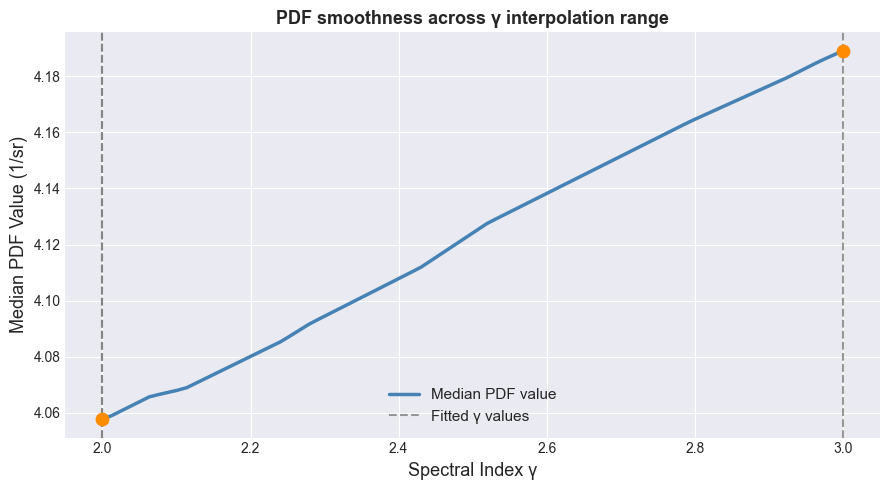

✓ Median PDF is monotone across the γ range.


In [12]:
gammas_fine = np.linspace(
    wrapper.spectral_indices[0], wrapper.spectral_indices[-1], 80
)

median_pdfs = np.array([
    np.median(wrapper.evaluate_pdf(test_events, gamma=g))
    for g in gammas_fine
])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gammas_fine, median_pdfs, 'steelblue', linewidth=2.5, label='Median PDF value')

for gamma in wrapper.spectral_indices:
    ax.axvline(gamma, color='gray', linestyle='--', alpha=0.8, linewidth=1.5)
ax.axvline(wrapper.spectral_indices[0], color='gray', linestyle='--',
           alpha=0.8, linewidth=1.5, label='Fitted γ values')

# Mark the fitted-only values with circles for comparison
for g_idx, gamma in enumerate(wrapper.spectral_indices):
    m = np.median(wrapper.evaluate_pdf(test_events, gamma=gamma))
    ax.scatter([gamma], [m], s=80, color='darkorange', zorder=5)

ax.set_xlabel('Spectral Index γ', fontsize=13)
ax.set_ylabel('Median PDF Value (1/sr)', fontsize=13)
ax.set_title('PDF smoothness across γ interpolation range', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Check for non-monotonicity (a sign of interpolation pathology)
diffs = np.diff(median_pdfs)
if np.all(diffs >= 0) or np.all(diffs <= 0):
    print("✓ Median PDF is monotone across the γ range.")
else:
    n_reversals = np.sum(diffs[:-1] * diffs[1:] < 0)
    print(f"⚠ Found {n_reversals} reversals in median PDF — check interpolation.")

## Summary

| Step | What to check |
|------|---------------|
| MC angular errors (§1a) | Histograms should match red King curves |
| Fitted α, β (§3) | Should closely recover the true dashed-line values |
| PDF vs distance (§5) | Blue scatter should follow red fitted curve |
| Normalization (§6) | ∫PDF dΩ should be ≈ 1.00 for all γ |
| γ interpolation (§7) | Median PDF should be smooth, no kinks |

If all checks pass, the wrapper is correctly fitting, interpolating, and evaluating the King spatial PDF and is ready to use in a likelihood-based point source analysis.